In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import pairwise_distances
from sklearn.manifold import MDS, TSNE

In [5]:
iris = load_iris(as_frame=True)
X = iris.data
y = iris.target
target_names = iris.target_names

print(X.shape)
X.head()

(150, 4)


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [6]:
scaler = StandardScaler()
X_scaled = pd.DataFrame(
    scaler.fit_transform(X),
    columns=X.columns
)

X_scaled.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,-0.900681,1.019004,-1.340227,-1.315444
1,-1.143017,-0.131979,-1.340227,-1.315444
2,-1.385353,0.328414,-1.397064,-1.315444
3,-1.506521,0.098217,-1.283389,-1.315444
4,-1.021849,1.249201,-1.340227,-1.315444


In [7]:
def plot_2d(Z, y, title):
    plt.figure(figsize=(6, 5))
    for label in np.unique(y):
        plt.scatter(
            Z[y == label, 0],
            Z[y == label, 1],
            label=target_names[label],
            s=45
        )
    plt.xlabel("Component 1")
    plt.ylabel("Component 2")
    plt.title(title)
    plt.legend()
    plt.show()

/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_mds.py:754: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(


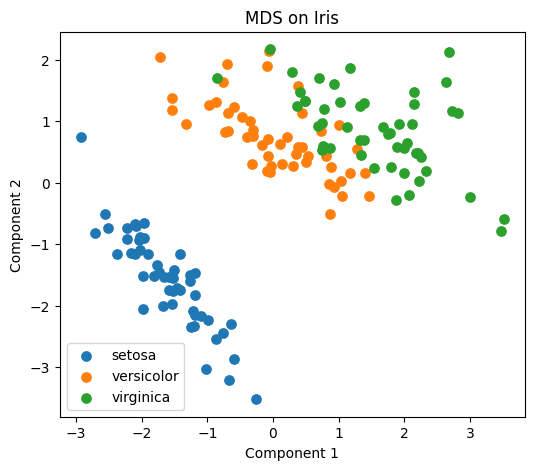

In [8]:
mds = MDS(
    n_components=2,
    metric_mds=True,
    random_state=42,
    n_init=4,
    max_iter=300
)

X_mds = mds.fit_transform(X_scaled)
plot_2d(X_mds, y, "MDS on Iris")

In [9]:
print(mds.embedding_.shape)
mds.embedding_[:5]

(150, 2)


array([[-1.52739622, -1.75785399],
       [-2.08681587, -0.7025374 ],
       [-2.10703674, -1.15466869],
       [-2.21641915, -0.9090791 ],
       [-1.53318567, -1.96524715]])

In [10]:
print("stress_ =", mds.stress_)

stress_ = 235.1048099396981


In [11]:
import numpy as np
from sklearn.metrics import pairwise_distances

D = pairwise_distances(X)              # original distances
D_hat = pairwise_distances(X_mds)      # embedded distances

normalized_stress = np.sqrt(mds.stress_ / (D**2).sum())

print("Normalized stress =", normalized_stress)

Normalized stress = 0.03391395460554054


In [12]:
print(mds.dissimilarity_matrix_.shape)
mds.dissimilarity_matrix_[:5, :5]

(150, 150)


array([[0.        , 1.17621868, 0.84560741, 1.10368502, 0.26013882],
       [1.17621868, 0.        , 0.52337301, 0.43399991, 1.3864853 ],
       [0.84560741, 0.52337301, 0.        , 0.28389113, 0.99157157],
       [1.10368502, 0.43399991, 0.28389113, 0.        , 1.25016028],
       [0.26013882, 1.3864853 , 0.99157157, 1.25016028, 0.        ]])

In [13]:
print("n_iter_ =", mds.n_iter_)

n_iter_ = 82


In [ ]:
print("n_features_in_ =", mds.n_features_in_)

n_features_in_ = 4


In [ ]:
print(mds.feature_names_in_)

['sepal length (cm)' 'sepal width (cm)' 'petal length (cm)'
 'petal width (cm)']


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_mds.py:754: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(


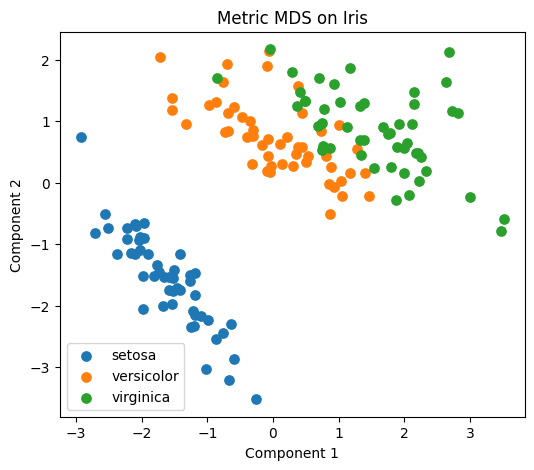

Metric MDS stress_: 235.1048099396981


In [ ]:
mds_metric = MDS(
    n_components=2,
    metric_mds=True,
    random_state=42,
    n_init=4
)

Z_metric = mds_metric.fit_transform(X_scaled)
plot_2d(Z_metric, y, "Metric MDS on Iris")
print("Metric MDS stress_:", mds_metric.stress_)

/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_mds.py:754: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(


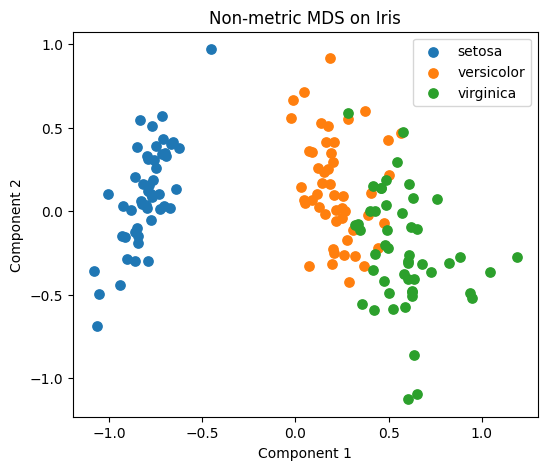

Non-metric MDS stress_: 0.04220156269634556


In [ ]:
mds_nonmetric = MDS(
    n_components=2,
    metric_mds=False,
    random_state=42,
    n_init=4
)

Z_nonmetric = mds_nonmetric.fit_transform(X_scaled)
plot_2d(Z_nonmetric, y, "Non-metric MDS on Iris")
print("Non-metric MDS stress_:", mds_nonmetric.stress_)

/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_mds.py:744: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9. To suppress this warning, provide some value of `n_init`.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_mds.py:754: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(


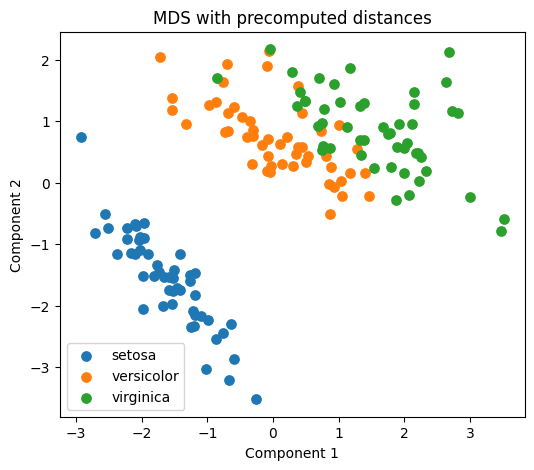

In [ ]:
D = pairwise_distances(X_scaled, metric="euclidean")

mds_pre = MDS(
    n_components=2,
    metric="precomputed",
    metric_mds=True,
    random_state=42
)

Z_pre = mds_pre.fit_transform(D)
plot_2d(Z_pre, y, "MDS with precomputed distances")

In [14]:
mds_3d = MDS(
    n_components=3,
    metric_mds=True,
    random_state=42
)

Z_3d = mds_3d.fit_transform(X_scaled)
print(Z_3d.shape)
print("3D MDS stress_:", mds_3d.stress_)

/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_mds.py:744: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9. To suppress this warning, provide some value of `n_init`.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_mds.py:754: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(


(150, 3)
3D MDS stress_: 7.0076444949643655


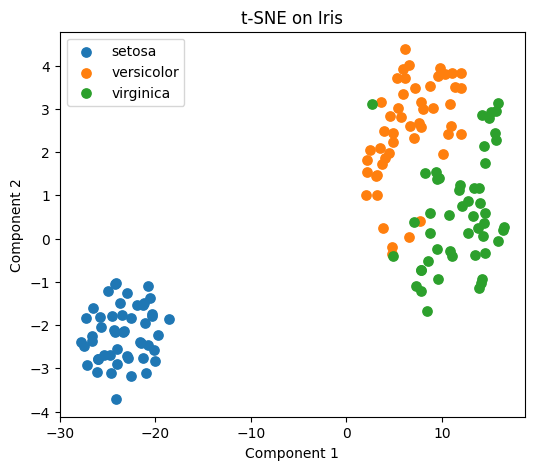

In [15]:
tsne = TSNE(
    n_components=2,
    perplexity=30,
    learning_rate="auto",
    init="pca",
    max_iter=1000,
    random_state=42
)

X_tsne = tsne.fit_transform(X_scaled)
plot_2d(X_tsne, y, "t-SNE on Iris")

In [ ]:
print(tsne.embedding_.shape)
tsne.embedding_[:5]

(150, 2)


array([[-24.310734 ,  -2.1122737],
       [-20.536928 ,  -1.3836074],
       [-21.545553 ,  -2.4164944],
       [-20.773043 ,  -2.4609888],
       [-24.798649 ,  -2.6877975]], dtype=float32)

In [17]:
print("kl_divergence_ =", tsne.kl_divergence_)

kl_divergence_ = 0.1471702605485916


In [18]:
print("learning_rate_ =", tsne.learning_rate_)

learning_rate_ = 50.0


In [19]:
print("n_iter_ =", tsne.n_iter_)

n_iter_ = 999


In [20]:
print("n_features_in_ =", tsne.n_features_in_)

n_features_in_ = 4


In [ ]:
print(tsne.feature_names_in_)

['sepal length (cm)' 'sepal width (cm)' 'petal length (cm)'
 'petal width (cm)']


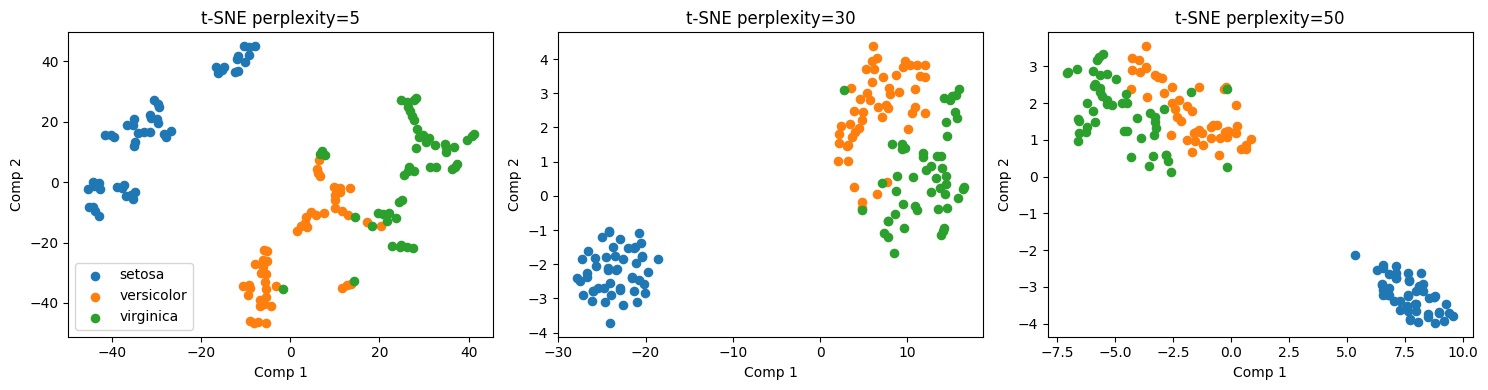

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, p in zip(axes, [5, 30, 50]):
    Z = TSNE(
        n_components=2,
        perplexity=p,
        learning_rate="auto",
        init="pca",
        max_iter=1000,
        random_state=42
    ).fit_transform(X_scaled)

    for label in np.unique(y):
        ax.scatter(
            Z[y == label, 0],
            Z[y == label, 1],
            label=target_names[label],
            s=35
        )
    ax.set_title(f"t-SNE perplexity={p}")
    ax.set_xlabel("Comp 1")
    ax.set_ylabel("Comp 2")

axes[0].legend()
plt.tight_layout()
plt.show()

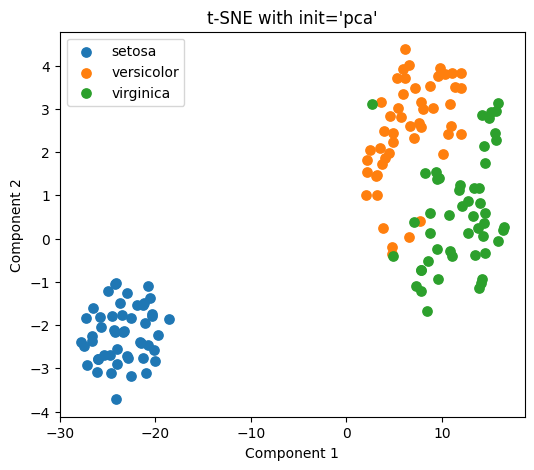

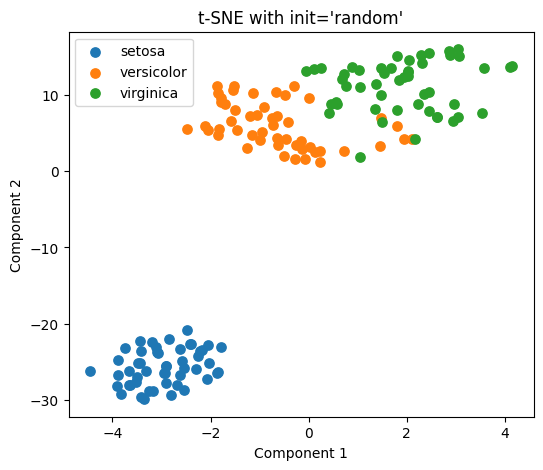

In [ ]:
tsne_pca = TSNE(
    n_components=2,
    init="pca",
    perplexity=30,
    learning_rate="auto",
    max_iter=1000,
    random_state=42
)
Z_pca = tsne_pca.fit_transform(X_scaled)

tsne_random = TSNE(
    n_components=2,
    init="random",
    perplexity=30,
    learning_rate="auto",
    max_iter=1000,
    random_state=42
)
Z_random = tsne_random.fit_transform(X_scaled)

plot_2d(Z_pca, y, "t-SNE with init='pca'")
plot_2d(Z_random, y, "t-SNE with init='random'")

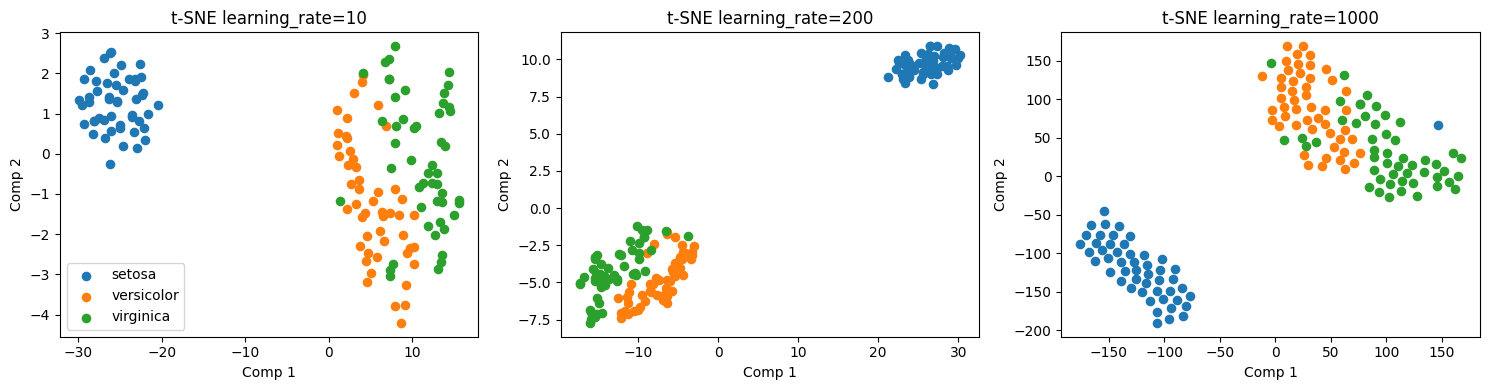

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, lr in zip(axes, [10, 200, 1000]):
    Z = TSNE(
        n_components=2,
        perplexity=30,
        learning_rate=lr,
        init="pca",
        max_iter=1000,
        random_state=42
    ).fit_transform(X_scaled)

    for label in np.unique(y):
        ax.scatter(
            Z[y == label, 0],
            Z[y == label, 1],
            s=35,
            label=target_names[label]
        )
    ax.set_title(f"t-SNE learning_rate={lr}")
    ax.set_xlabel("Comp 1")
    ax.set_ylabel("Comp 2")

axes[0].legend()
plt.tight_layout()
plt.show()

/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_mds.py:744: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9. To suppress this warning, provide some value of `n_init`.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_mds.py:754: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(


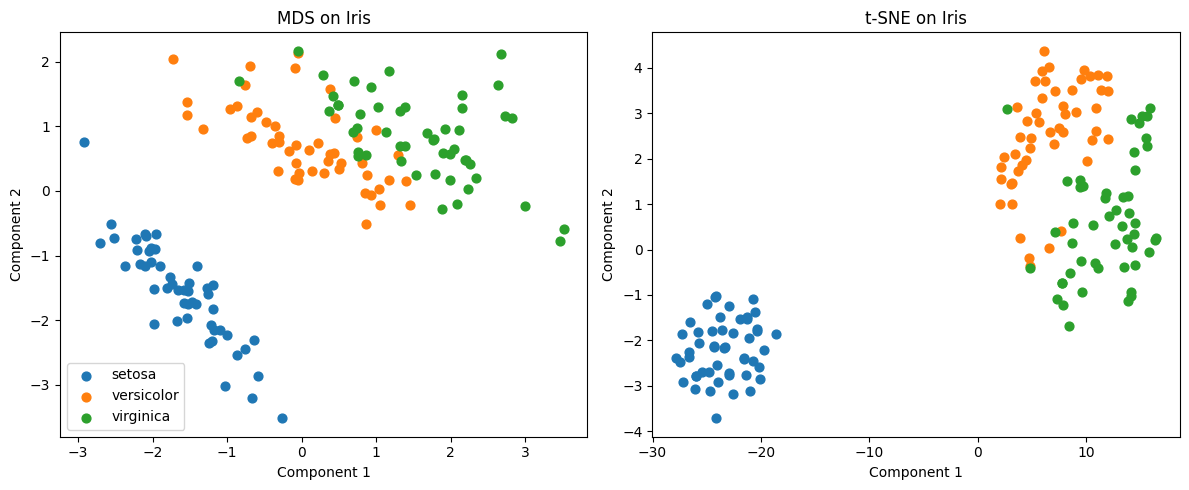

In [ ]:
mds = MDS(n_components=2, metric_mds=True, random_state=42)
Z_mds = mds.fit_transform(X_scaled)

tsne = TSNE(
    n_components=2,
    perplexity=30,
    learning_rate="auto",
    init="pca",
    max_iter=1000,
    random_state=42
)
Z_tsne = tsne.fit_transform(X_scaled)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for label in np.unique(y):
    axes[0].scatter(Z_mds[y == label, 0], Z_mds[y == label, 1], label=target_names[label], s=40)
axes[0].set_title("MDS on Iris")
axes[0].set_xlabel("Component 1")
axes[0].set_ylabel("Component 2")

for label in np.unique(y):
    axes[1].scatter(Z_tsne[y == label, 0], Z_tsne[y == label, 1], label=target_names[label], s=40)
axes[1].set_title("t-SNE on Iris")
axes[1].set_xlabel("Component 1")
axes[1].set_ylabel("Component 2")

axes[0].legend()
plt.tight_layout()
plt.show()